In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import binom #binom(a,b)等价于C(a,b)  二项的意思
#计算二项分布概率 dinom(a,b,c) b次出现a的概率,每次有c的概率出现a
from scipy.stats import binom as binom_dist 

In [15]:
def build_binomial_tree(ax,n):
    for i in np.arange(n):
        Nodes_y = np.linspace(-i,i,i+1)
        #concatenate是做什么的进行数组拼接
        #这里将会有两个0点,是为了绘制的时候一次向上一次向下一次,不能同时从一个点出发延伸成两个点
        B_y = np.concatenate((Nodes_y + 1,Nodes_y - 1)) 
        B_x = np.zeros_like(B_y) + i + 1 
        A_y = np.concatenate((Nodes_y,Nodes_y)) 
        A_x = np.zeros_like(A_y)+i
        x_AB = np.stack((A_x,B_x))
        y_AB = np.stack((A_y,B_y))

        ax.plot(x_AB,y_AB,'o-',color = '#92D050',
               markerfacecolor = '#0099FF',
               markeredgecolor = None)

        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_xlim(0,n)
        ax.set_ylim(-n - 1,n + 1)
        ax.set_title('Binomial Tree')
        ax.grid(False)

In [16]:
def plot_binomial_coefficients(ax,n):
    """二项式系数柱状图"""
    degrees = np.linspace(n,0,n+1) #可以倒序
    poly_coeffs = binom(n,degrees) 
    locations = np.linspace(-n,n,n+1)
    ax.barh(locations,poly_coeffs,align = 'center',color = 'blue')

    for i,(loc,coeff) in enumerate(zip(locations,poly_coeffs)):
        ax.text(coeff + poly_coeffs.max() * 0.1,loc,str(int(coeff)))

    ax.set_ylim(-n - 1, n + 1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title("Binomial Coefficients")
    ax.grid(False)

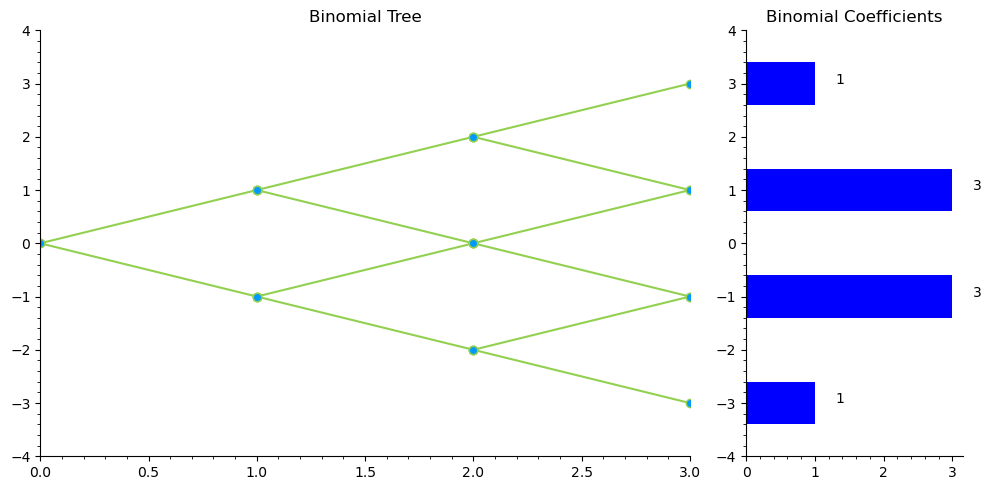

In [17]:
n = 3
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios' : [3,1]})#
build_binomial_tree(axes[0],n)
plot_binomial_coefficients(axes[1],n)
plt.tight_layout()
plt.show()

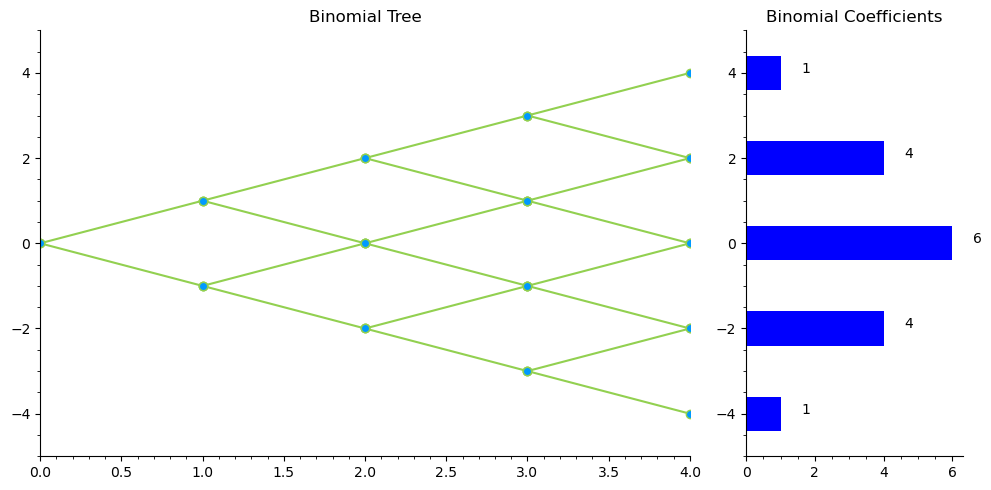

In [18]:
n = 4
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios' : [3,1]})#
build_binomial_tree(axes[0],n)
plot_binomial_coefficients(axes[1],n)
plt.tight_layout()
plt.show()

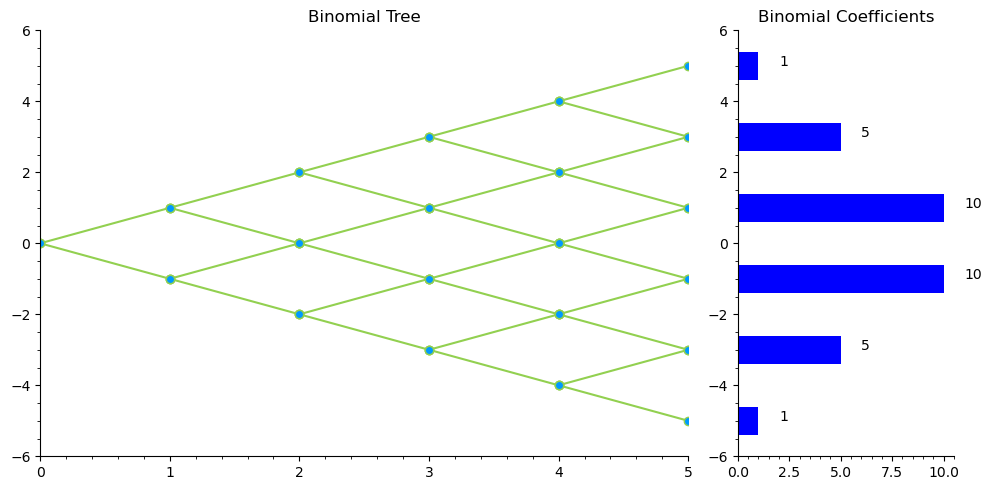

In [19]:
n = 5
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios' : [3,1]})#
build_binomial_tree(axes[0],n)
plot_binomial_coefficients(axes[1],n)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
p = plt.rcParams  # 获取默认绘图参数
p["font.weight"] = "light"  # 设置字体粗细为 light
p["ytick.minor.visible"] = True  # 显示 y 轴的小刻度
p["xtick.minor.visible"] = True  # 显示 x 轴的小刻度
p["axes.grid"] = True  # 启用坐标轴网格
p["grid.color"] = "0.5"  # 设置网格颜色为灰色
p["grid.linewidth"] = 0.5  # 设置网格线宽度

In [22]:
num_toss = 100
#生成整数随机数,low - (high - 1)之间 ,size是生成的形状
toss = np.random.randint(low = 0,high = 2,size = (num_toss,1))

In [23]:
up = (toss == 1)#生成布尔数组,布尔数组默认是true和false,用于运算才是0和1

In [24]:
iteration = np.arange(1,num_toss + 1)

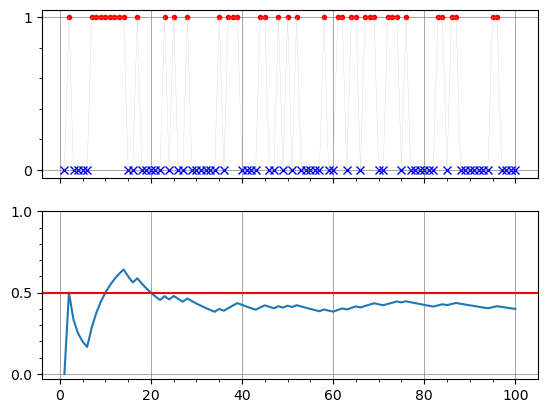

In [25]:
fig,axs = plt.subplots(2,1,sharex = True)

axs[0].plot(iteration[up.flatten()],toss[up],
            color = 'r',marker = '.',linestyle = 'None')
axs[0].plot(iteration[~up.flatten()],toss[~up],
            color = 'b',marker = 'x',linestyle = 'None')#~用于布尔数组求反
axs[0].plot(iteration,toss,color = '0.8',lw = 0.2)
axs[0].set_yticks([0,1])

cum_mean = np.cumsum(toss) / iteration

axs[1].plot(iteration,cum_mean)
axs[1].axhline(y = 0.5,color = 'r')
axs[1].set_yticks([0,0.5,1])

In [30]:
def plot_binomial_probabilities(ax,n,p):

    x = np.arange(0,n+1) #成功的次数列表
    p_x = binom_dist.pmf(x,n,p) #依次按照成功的次数求概率,得到列表
    locations = np.linspace(-n,n,n+1)
    ax.barh(locations,p_x,align = 'center',color = 'blue')

    for i,(loc,prob) in enumerate(zip(locations,p_x)):
        ax.text(prob + p_x.max() * 0.1 ,loc,f'{prob:.4f}')

    ax.set_ylim(-n - 1,n+1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('Binomial Probabilities')
    ax.grid(False)

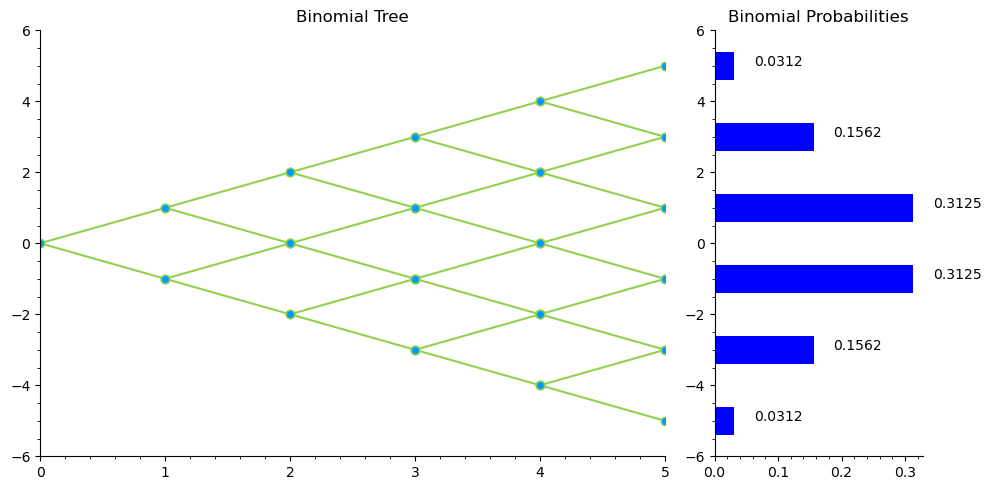

In [32]:
n = 5
#width的宽度就是ax的宽度的比例
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios':[3,1]})
build_binomial_tree(axes[0],n)
plot_binomial_probabilities(axes[1],n,0.5)
plt.tight_layout()
plt.show()

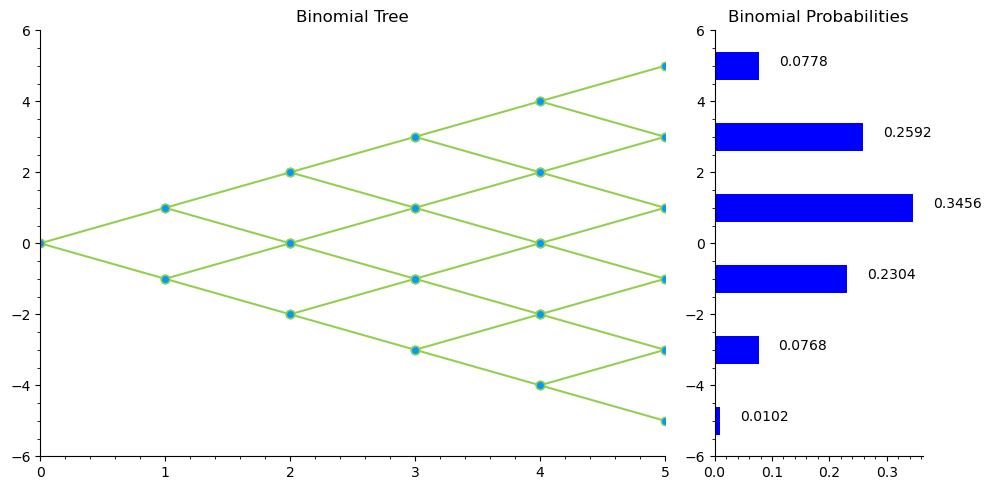

In [33]:
n = 5
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios':[3,1]})
build_binomial_tree(axes[0],n)
plot_binomial_probabilities(axes[1],n,0.6)
plt.tight_layout()
plt.show()

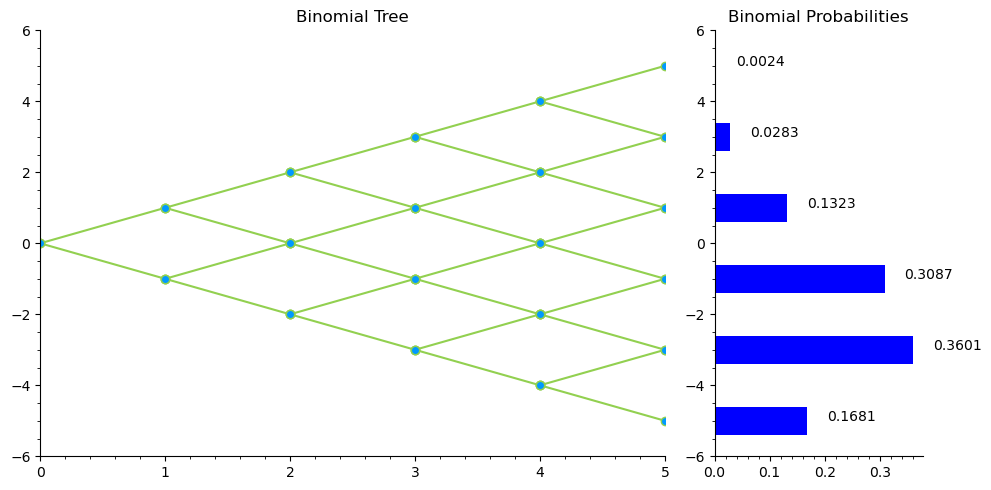

In [34]:
n = 5
#width的宽度就是ax的宽度的比例
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios':[3,1]})
build_binomial_tree(axes[0],n)
plot_binomial_probabilities(axes[1],n,0.3)
plt.tight_layout()
plt.show()

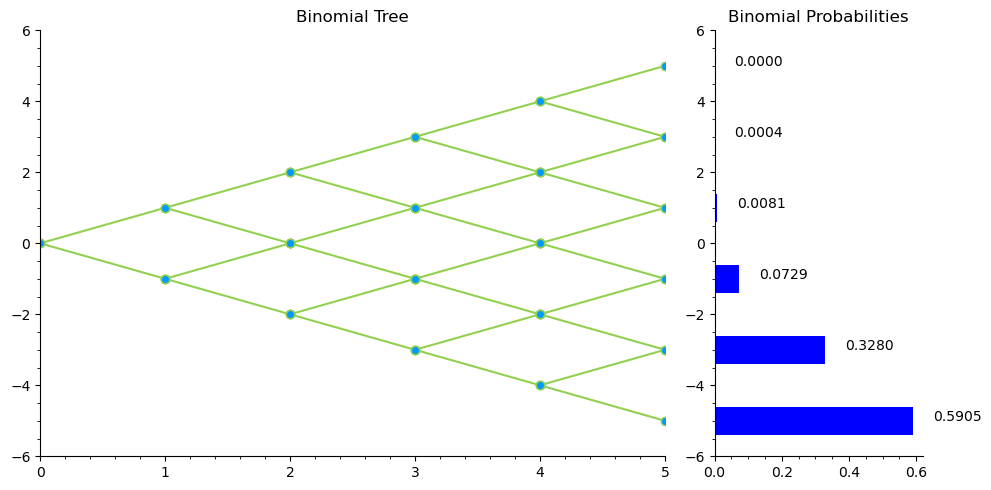

In [35]:
n = 5
#width的宽度就是ax的宽度的比例
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios':[3,1]})
build_binomial_tree(axes[0],n)
plot_binomial_probabilities(axes[1],n,0.1)
plt.tight_layout()
plt.show()

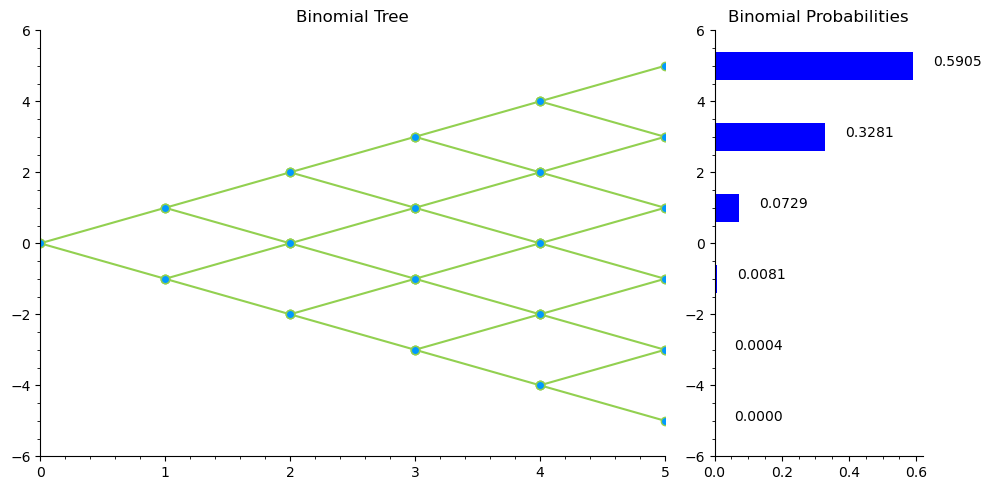

In [36]:
n = 5
#width的宽度就是ax的宽度的比例
fig,axes = plt.subplots(1,2,figsize = (10,5),gridspec_kw = {'width_ratios':[3,1]})
build_binomial_tree(axes[0],n)
plot_binomial_probabilities(axes[1],n,0.9)
plt.tight_layout()
plt.show()